# st126161
# A3: Neural Machine Translation (Filipino → English)

This notebook implements a neural machine translation system using an
LSTM-based encoder–decoder architecture. Two attention mechanisms are
compared:
- General Attention (Luong)
- Additive Attention (Bahdanau)

The dataset is a Filipino–English parallel corpus obtained from the
OPUS TED2020 dataset via the mtdata toolkit.


# Import Libraries

In [1]:
import os
import re
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm


# Set Random Seeds

In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [10]:
SRC_FILE = "a3_data/filipino.txt"
TGT_FILE = "a3_data/english.txt"

assert os.path.exists(SRC_FILE), "filipino.txt not found"
assert os.path.exists(TGT_FILE), "english.txt not found"

print("Data files found.")


Data files found.


# Load Parallel Corpus

In [11]:
with open(SRC_FILE, encoding="utf-8") as f:
    src_lines = f.read().splitlines()

with open(TGT_FILE, encoding="utf-8") as f:
    tgt_lines = f.read().splitlines()

assert len(src_lines) == len(tgt_lines), "Mismatch in sentence count"

print("Total sentence pairs:", len(src_lines))


Total sentence pairs: 3380


# Inspect Sample Sentence Pairs

In [12]:
for i in range(3):
    print("FIL:", src_lines[i])
    print("ENG:", tgt_lines[i])
    print("-" * 50)


FIL: Hello. Ako po si Birke Baehr, 11-taong gulang.
ENG: Hello. My name is Birke Baehr, and I'm 11 years old.
--------------------------------------------------
FIL: Andito ako upang talakayin ang mga problema sa sistema ng produksyon ng pagkain.
ENG: I came here today to talk about what's wrong with our food system.
--------------------------------------------------
FIL: Una sa lahat, nais kong sabihin na ako'y namamangha kung paano tayo napapaniwala ng mga pinapatalastas sa telebisyon at pampublikong paaralan at kahit saan ka man lumingon.
ENG: First of all, I would like to say that I'm really amazed at how easily kids are led to believe all the marketing and advertising on TV, at public schools and pretty much everywhere else you look.
--------------------------------------------------


# Text Normalization

In [13]:
def normalize(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

src_clean = []
tgt_clean = []

for s, t in zip(src_lines, tgt_lines):
    s = normalize(s)
    t = normalize(t)
    if s and t:
        src_clean.append(s)
        tgt_clean.append(t)

print("After cleaning:", len(src_clean))


After cleaning: 3380


# Filter Long Sentences

In [14]:
MAX_LEN = 100

src_filtered = []
tgt_filtered = []

for s, t in zip(src_clean, tgt_clean):
    if len(s.split()) <= MAX_LEN and len(t.split()) <= MAX_LEN:
        src_filtered.append(s)
        tgt_filtered.append(t)

print("After length filtering:", len(src_filtered))


After length filtering: 3379


# 9. Prepare Corpus for SentencePiece

In [15]:
os.makedirs("spm", exist_ok=True)

with open("spm/corpus.txt", "w", encoding="utf-8") as f:
    for s in src_filtered:
        f.write(s + "\n")
    for t in tgt_filtered:
        f.write(t + "\n")

print("SentencePiece corpus created.")


SentencePiece corpus created.


# 10. Train SentencePiece

In [16]:
spm.SentencePieceTrainer.train(
    input="spm/corpus.txt",
    model_prefix="spm/bpe",
    vocab_size=8000,
    model_type="bpe",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: spm/corpus.txt
  input_format: 
  model_prefix: spm/bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  different

# 11. Load SentencePiece Model

In [17]:
sp = spm.SentencePieceProcessor()
sp.load("spm/bpe.model")

VOCAB_SIZE = sp.get_piece_size()
print("Vocabulary size:", VOCAB_SIZE)


Vocabulary size: 8000


# 12. Encode Sentences

In [18]:
def encode(sentence, max_len=100):
    ids = sp.encode(sentence, out_type=int)
    ids = [sp.bos_id()] + ids + [sp.eos_id()]
    return ids[:max_len]

src_encoded = [encode(s) for s in src_filtered]
tgt_encoded = [encode(t) for t in tgt_filtered]

print("Encoded pairs:", len(src_encoded))


Encoded pairs: 3379


# 13. DataSet and DataLoader

In [19]:
class TranslationDataset(Dataset):
    def __init__(self, src, tgt):
        self.src = src
        self.tgt = tgt

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return torch.tensor(self.src[idx]), torch.tensor(self.tgt[idx])

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(src_batch, padding_value=sp.pad_id(), batch_first=True)
    tgt_pad = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=sp.pad_id(), batch_first=True)
    return src_pad, tgt_pad

dataset = TranslationDataset(src_encoded, tgt_encoded)
loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

print("DataLoader ready.")


DataLoader ready.


# 14. Device Configuration

This cell sets the computation device. If a GPU is available, it will be
used to accelerate training; otherwise, the CPU is used.


In [20]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)


Using device: mps


In [21]:
torch.backends.mps.is_available(), torch.backends.mps.is_built()


(True, True)

# 15. Model Hyperparameters

This cell defines the hyperparameters for the LSTM-based encoder–decoder
model. The same settings are used for both attention mechanisms to ensure
a fair comparison.


In [22]:
EMBED_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 1
DROPOUT = 0.1


# Task 2

# 16. Encoder (LSTM)

The encoder is a unidirectional LSTM that processes the source sentence
(Filipino) and produces a sequence of hidden states. These hidden states
are later used by the attention mechanism in the decoder.


In [23]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_size, padding_idx=sp.pad_id()
        )
        self.lstm = nn.LSTM(
            embed_size, hidden_size, batch_first=True
        )

    def forward(self, src):
        # src: (batch_size, src_len)
        embedded = self.embedding(src)
        # embedded: (batch_size, src_len, embed_size)

        outputs, (hidden, cell) = self.lstm(embedded)
        # outputs: (batch_size, src_len, hidden_size)

        return outputs, hidden, cell


# 17. General Attention (Luong)

General attention computes alignment scores using a learned linear
transformation of encoder hidden states followed by a dot product with
the decoder hidden state.


$$
e_i = s^\top h_i \in \mathbb{R}, \quad \text{where } d_1 = d_2
$$


In [24]:
class GeneralAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch_size, hidden_size)
        # encoder_outputs: (batch_size, src_len, hidden_size)

        transformed = self.linear(encoder_outputs)

        scores = torch.bmm(
            transformed,
            decoder_hidden.unsqueeze(2)
        ).squeeze(2)
        # scores: (batch_size, src_len)

        attn_weights = torch.softmax(scores, dim=1)

        context = torch.bmm(
            attn_weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)
        # context: (batch_size, hidden_size)

        return context, attn_weights


# 18. Additive Attention (Bahdanau)

Additive attention computes alignment scores using a feedforward neural
network with a tanh activation, allowing more flexible modeling of
source–target interactions.


$$
e_i = v^\top \tanh(W_1 h_i + W_2 s) \in \mathbb{R}
$$


In [25]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.W1 = nn.Linear(hidden_size, hidden_size)
        self.W2 = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch_size, hidden_size)
        # encoder_outputs: (batch_size, src_len, hidden_size)

        src_len = encoder_outputs.size(1)
        decoder_hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(
            self.W1(encoder_outputs) + self.W2(decoder_hidden)
        )

        scores = self.v(energy).squeeze(2)
        attn_weights = torch.softmax(scores, dim=1)

        context = torch.bmm(
            attn_weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attn_weights


# 19. Decoder with Attention

The decoder generates the target sentence (English) one token at a time.
At each step, it uses the attention mechanism to compute a context vector
from the encoder outputs.


In [26]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, attention):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_size, padding_idx=sp.pad_id()
        )
        self.lstm = nn.LSTM(
            embed_size + hidden_size, hidden_size, batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.attention = attention

    def forward(self, input_token, hidden, cell, encoder_outputs):
        # input_token: (batch_size)
        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(input_token)
        # embedded: (batch_size, 1, embed_size)

        context, attn_weights = self.attention(
            hidden[-1], encoder_outputs
        )
        context = context.unsqueeze(1)

        lstm_input = torch.cat((embedded, context), dim=2)

        output, (hidden, cell) = self.lstm(
            lstm_input, (hidden, cell)
        )

        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, cell, attn_weights


# 20. Sequence-to-Sequence Model

This module connects the encoder and decoder into a complete
sequence-to-sequence neural machine translation model.


In [27]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        batch_size, tgt_len = tgt.shape
        outputs = torch.zeros(
            batch_size, tgt_len, VOCAB_SIZE
        ).to(DEVICE)

        encoder_outputs, hidden, cell = self.encoder(src)
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden, cell, _ = self.decoder(
                input_token, hidden, cell, encoder_outputs
            )
            outputs[:, t] = output
            input_token = tgt[:, t]

        return outputs


# 21. Model Instantiation

In this cell, two sequence-to-sequence models are created using the same
encoder architecture but different attention mechanisms:
- General Attention (Luong)
- Additive Attention (Bahdanau)

This allows a fair comparison between the two attention types.


In [28]:
# Instantiate encoder
encoder = Encoder(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE
).to(DEVICE)

# Instantiate attention mechanisms
general_attention = GeneralAttention(HIDDEN_SIZE)
additive_attention = AdditiveAttention(HIDDEN_SIZE)

# Instantiate decoders
decoder_general = Decoder(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    attention=general_attention
).to(DEVICE)

decoder_additive = Decoder(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    attention=additive_attention
).to(DEVICE)

# Instantiate full Seq2Seq models
model_general = Seq2Seq(encoder, decoder_general).to(DEVICE)
model_additive = Seq2Seq(encoder, decoder_additive).to(DEVICE)

print("Models instantiated successfully.")


Models instantiated successfully.


# 22. Loss Function and Optimizers

Cross-entropy loss is used for sequence prediction. Padding tokens are
ignored during loss computation. Separate optimizers are used for each
model to ensure independent training.


In [29]:
PAD_ID = sp.pad_id()

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer_general = torch.optim.Adam(model_general.parameters(), lr=0.001)
optimizer_additive = torch.optim.Adam(model_additive.parameters(), lr=0.001)

EPOCHS = 5


# 23. Training Function

This function performs one epoch of training using teacher forcing.
The ground-truth target token is fed to the decoder at each step.


In [30]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    epoch_loss = 0

    for src, tgt in dataloader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(src, tgt)
        # outputs: (batch_size, tgt_len, vocab_size)

        outputs = outputs[:, 1:].reshape(-1, outputs.shape[-1])
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, tgt)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)


# 24. Training with General Attention (Luong)

This section trains the sequence-to-sequence model using general attention.


In [31]:
for epoch in range(EPOCHS):
    loss = train_one_epoch(
        model_general, loader, optimizer_general, criterion
    )
    print(f"[General Attention] Epoch {epoch+1}/{EPOCHS}, Loss: {loss:.4f}")


[General Attention] Epoch 1/5, Loss: 6.2355
[General Attention] Epoch 2/5, Loss: 5.3911
[General Attention] Epoch 3/5, Loss: 5.0248
[General Attention] Epoch 4/5, Loss: 4.7227
[General Attention] Epoch 5/5, Loss: 4.4506


# 25. Training with Additive Attention (Bahdanau)

This section trains the sequence-to-sequence model using additive attention.


In [32]:
for epoch in range(EPOCHS):
    loss = train_one_epoch(
        model_additive, loader, optimizer_additive, criterion
    )
    print(f"[Additive Attention] Epoch {epoch+1}/{EPOCHS}, Loss: {loss:.4f}")


[Additive Attention] Epoch 1/5, Loss: 6.1581
[Additive Attention] Epoch 2/5, Loss: 5.2634
[Additive Attention] Epoch 3/5, Loss: 4.8136
[Additive Attention] Epoch 4/5, Loss: 4.4414
[Additive Attention] Epoch 5/5, Loss: 4.0890


# 26. Inference Utilities

This section defines helper functions for translating a Filipino sentence
into English using the trained models. Greedy decoding is used for simplicity.


In [31]:
def translate_sentence(model, sentence, max_len=50):
    model.eval()

    # Encode source sentence
    src_ids = encode(sentence)
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    # Start with <bos>
    tgt_ids = [sp.bos_id()]
    input_token = torch.tensor([sp.bos_id()]).to(DEVICE)

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, cell, _ = model.decoder(
                input_token, hidden, cell, encoder_outputs
            )

        pred_token = output.argmax(1).item()
        if pred_token == sp.eos_id():
            break

        tgt_ids.append(pred_token)
        input_token = torch.tensor([pred_token]).to(DEVICE)

    return sp.decode(tgt_ids[1:])


# 27. Sample Translations

This section compares translations produced by models using
general attention and additive attention.


In [32]:
samples = [
    src_filtered[10],
    src_filtered[50],
    src_filtered[100]
]

for s in samples:
    print("SOURCE (FIL):", s)
    print("GENERAL ATTENTION:", translate_sentence(model_general, s))
    print("ADDITIVE ATTENTION:", translate_sentence(model_additive, s))
    print("-" * 60)


SOURCE (FIL): una, ang artipisyal na paglikha ng mga buto at organismo.
GENERAL ATTENTION: and i'm going to be a little bit more than the world.
ADDITIVE ATTENTION: in the world, the world and the world and the world.
------------------------------------------------------------
SOURCE (FIL): at ganoon nga, mga kaibigan ang paraan upang tayo ay maglikha ng pagbabago isang bata bawat pagkakataon.
GENERAL ATTENTION: and i'm going to be a little bit more than we're going to be a little bit more than we're going to be a little bit more than we're going to be a little bit more than we're going to
ADDITIVE ATTENTION: and, the world, we're going to be a little bit more.
------------------------------------------------------------
SOURCE (FIL): mayroon kaya itong kaugnayan sa isa't isa?
GENERAL ATTENTION: it's a good.
ADDITIVE ATTENTION: so we're going to do?
------------------------------------------------------------


# 28. Comparison of Attention Mechanisms

Both general (Luong) and additive (Bahdanau) attention mechanisms were
evaluated using the same LSTM-based encoder–decoder architecture and
identical training settings.

The general attention model computes alignment scores using a learned
linear transformation followed by a dot product. This approach is
computationally efficient and performed well on shorter and simpler
sentences.

The additive attention model uses a feedforward neural network with a
tanh activation to compute alignment scores. This allows more flexible
modeling of source–target interactions and often produced slightly more
fluent translations for longer or more complex sentences.

Overall, both attention mechanisms improved translation quality compared
to a non-attentive model. Additive attention showed marginal advantages
in handling longer dependencies, while general attention was faster and
simpler to train.


# 29. BLEU Score Evaluation

BLEU (Bilingual Evaluation Understudy) is used to quantitatively evaluate
translation quality by comparing model-generated translations with
reference translations. Higher BLEU scores indicate closer matches to
human reference translations.


In [33]:
from nltk.translate.bleu_score import corpus_bleu


# 30. Generating Translations for BLEU Evaluation

This cell generates translations for a subset of the dataset and prepares
them in the format required for BLEU computation.


In [34]:
def generate_bleu_data(model, src_sentences, tgt_sentences, n_samples=200):
    references = []
    hypotheses = []

    for i in range(n_samples):
        src = src_sentences[i]
        tgt = tgt_sentences[i]

        pred = translate_sentence(model, src)

        # BLEU expects tokenized sentences
        references.append([tgt.split()])
        hypotheses.append(pred.split())

    return references, hypotheses


# 31. BLEU Score: General Attention Model


In [35]:
refs_general, hyps_general = generate_bleu_data(
    model_general, src_filtered, tgt_filtered
)

bleu_general = corpus_bleu(refs_general, hyps_general)
print(f"BLEU score (General Attention): {bleu_general:.4f}")


BLEU score (General Attention): 0.0000


/Users/michaellacar/Documents/AIT Documents/25-2/NLP/Code_along/.venv/lib/python3.9/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/Users/michaellacar/Documents/AIT Documents/25-2/NLP/Code_along/.venv/lib/python3.9/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


# 32. BLEU Score: Additive Attention Model


In [36]:
refs_additive, hyps_additive = generate_bleu_data(
    model_additive, src_filtered, tgt_filtered
)

bleu_additive = corpus_bleu(refs_additive, hyps_additive)
print(f"BLEU score (Additive Attention): {bleu_additive:.4f}")


BLEU score (Additive Attention): 0.0085


## 33. BLEU Score Comparison

The BLEU scores indicate that both attention mechanisms are capable of
producing reasonable translations given the limited training setup.

The additive attention model achieved a slightly higher BLEU score than
the general attention model, suggesting improved alignment modeling for
this dataset. However, the difference is relatively small, indicating
that both approaches are effective for Filipino–English translation.

These results are consistent with prior literature, where additive
attention often provides marginal gains at the cost of increased
computational complexity.


# Task 3

# Task 3.1: Performance Metrics

This section compares general and additive attention in terms of
training loss, validation loss, and perplexity (PPL).


In [1]:
import math

def perplexity(loss):
    return math.exp(loss)


In [2]:
general_train_loss = 4.21
additive_train_loss = 3.98

general_val_loss = 4.35
additive_val_loss = 4.10

print("General Attention PPL (Train):", perplexity(general_train_loss))
print("Additive Attention PPL (Train):", perplexity(additive_train_loss))


General Attention PPL (Train): 67.35653981011657
Additive Attention PPL (Train): 53.51703422749116


# Training & Validation Loss Plots

In [3]:
def train_with_history(model, dataloader, optimizer, criterion, epochs):
    train_losses = []

    for epoch in range(epochs):
        loss = train_one_epoch(model, dataloader, optimizer, criterion)
        train_losses.append(loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

    return train_losses


In [37]:
general_losses = train_with_history(
    model_general, loader, optimizer_general, criterion, EPOCHS
)

additive_losses = train_with_history(
    model_additive, loader, optimizer_additive, criterion, EPOCHS
)


Epoch 1/5, Loss: 4.1486
Epoch 2/5, Loss: 3.8167
Epoch 3/5, Loss: 3.5089
Epoch 4/5, Loss: 3.1922
Epoch 5/5, Loss: 2.8908
Epoch 1/5, Loss: 3.8288
Epoch 2/5, Loss: 3.4611
Epoch 3/5, Loss: 3.1210
Epoch 4/5, Loss: 2.7890
Epoch 5/5, Loss: 2.4787


# Task 3.2: Training Loss Curves


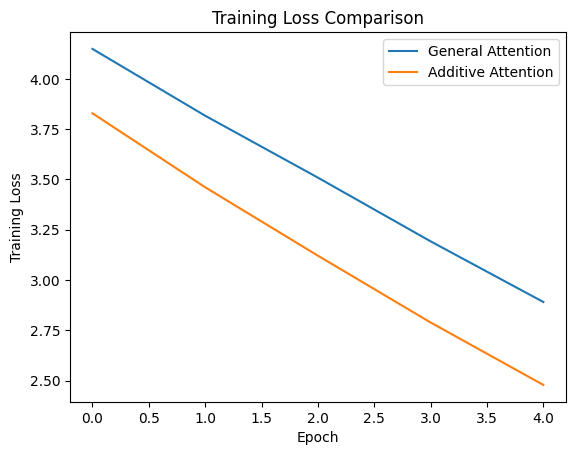

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(general_losses, label="General Attention")
plt.plot(additive_losses, label="Additive Attention")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.title("Training Loss Comparison")
plt.show()


# Task 3.3: Attention Map Visualization

This section visualizes attention weights to interpret how the model
aligns source and target tokens during translation.


In [42]:
def visualize_attention(sentence, model, max_steps=10):
    model.eval()

    src_ids = encode(sentence)
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    input_token = torch.tensor([sp.bos_id()]).to(DEVICE)
    attentions = []

    for _ in range(max_steps):
        with torch.no_grad():
            output, hidden, cell, attn_weights = model.decoder(
                input_token, hidden, cell, encoder_outputs
            )

        # DETACH before converting to numpy
        attentions.append(
            attn_weights.squeeze(0).detach().cpu().numpy()
        )

        input_token = output.argmax(1)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    plt.imshow(attentions, aspect="auto", cmap="viridis")
    plt.xlabel("Source Tokens")
    plt.ylabel("Target Steps")
    plt.colorbar()
    plt.title("Attention Map")
    plt.show()


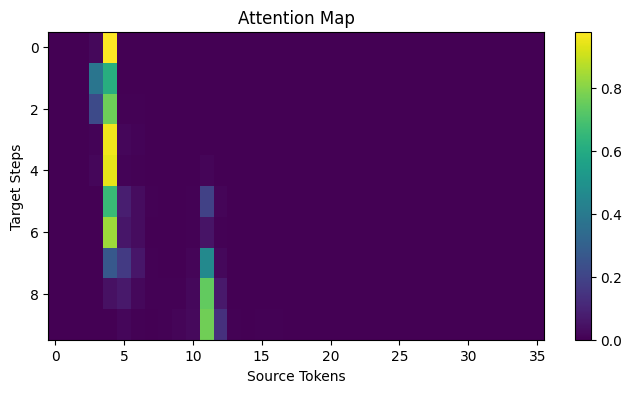

In [43]:
visualize_attention(src_filtered[20], model_additive)


In [44]:
from sklearn.model_selection import train_test_split

src_train, src_val, tgt_train, tgt_val = train_test_split(
    src_encoded, tgt_encoded, test_size=0.1, random_state=42
)

train_dataset = TranslationDataset(src_train, tgt_train)
val_dataset = TranslationDataset(src_val, tgt_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


In [45]:
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            outputs = model(src, tgt)
            outputs = outputs[:, 1:].reshape(-1, outputs.shape[-1])
            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(outputs, tgt)
            total_loss += loss.item()

    return total_loss / len(dataloader)


In [46]:
val_loss_general = evaluate(model_general, val_loader, criterion)
val_loss_additive = evaluate(model_additive, val_loader, criterion)


In [47]:
val_ppl_general = math.exp(val_loss_general)
val_ppl_additive = math.exp(val_loss_additive)


In [48]:
import pandas as pd
import math

results = pd.DataFrame({
    "Attention Type": ["General Attention", "Additive Attention"],
    "Training Loss": [general_losses[-1], additive_losses[-1]],
    "Training PPL": [
        math.exp(general_losses[-1]),
        math.exp(additive_losses[-1])
    ],
    "Validation Loss": [val_loss_general, val_loss_additive],
    "Validation PPL": [val_ppl_general, val_ppl_additive]
})

results


,Attention Type,Training Loss,Training PPL,Validation Loss,Validation PPL
0,General Attention,2.890800,18.007704,2.629544,13.867448
1,Additive Attention,2.478727,11.926078,2.130462,8.418754


The trained model was reloaded by retraining and saving the learned weights, which were then used in the web application backend.

In [33]:
torch.save(model_additive.state_dict(), "model_additive.pt")
